# RC-HAVOK Noise Mitigation: Denoising and Regularization
## Comparing 7 Mitigation Strategies for PWL Chua and Cubic Chua

**Base paper:** Bingöl, G.Y. & Günay, E. (2025). *Data-Driven Modeling of the Koopman Oriented Chua Circuit Based on Reservoir Computers.* ISCAS 2025.

**Scope:** Test whether Savitzky-Golay denoising, moving-average denoising, SVD-Hankel denoising, and/or ridge regression improve RC-HAVOK accuracy under Gaussian input noise for two Chua nonlinearities. No LSTM, GRU, Transformer, or neural-network forecasting. No reservoir-size or HAVOK-rank tuning.

## 0 · Imports & Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
from scipy.linalg import lstsq
from scipy.signal import savgol_filter
from scipy.ndimage import uniform_filter1d
from sklearn.utils.extmath import randomized_svd
warnings.filterwarnings("ignore")

# Seeds
ESN_SEED  = 42
N_REALIZ  = 20    # 20 realizations per noise level (N=20 for publication; reduced for runtime)

# Chua common parameters
IC    = [0.1, 0.2, 0.1]
DT    = 0.001
N     = 200_000
ALPHA_CHUA = 9.0
BETA       = 100 / 7
M0, M1     = -1/7, 2/7       # PWL
A_CUB, B_CUB = 1/16, -1/6   # Cubic

# RC-HAVOK (locked baseline)
N_RES   = 500
SR_TGT  = 0.9
CONN    = 0.2
LEAK    = 0.4
ISCALE  = 0.1
WASHOUT = 2_000
RANK    = 4
P_EMB   = 200
T_EVAL  = 13.0
N_EVAL  = int(T_EVAL / DT)

# Noise levels
ETA_LEVELS = [0.00, 0.01, 0.03, 0.05, 0.10]

# Mitigation parameters
SG_WINDOW    = 51      # Savitzky-Golay window (must be odd)
SG_ORDER     = 3
MA_WINDOW    = 51
SVD_KEEP     = 20      # Hankel SVD denoising: keep top-20 components
RIDGE_ALPHAS = [1e-8, 1e-6, 1e-4, 1e-3, 1e-2]
BEST_ALPHA   = 1e-4    # updated by alpha-sweep section

# Reference baselines from previous notebooks (N=20, seed=42)
PWL_REF = {
    0.00: 0.98715, 0.01: 0.42930, 0.03: 0.03180,
    0.05:-0.07480, 0.10:-0.01070
}
CUBIC_REF = {
    0.00: 0.99915, 0.01: 0.65222, 0.03: 0.52542,
    0.05: 0.48408, 0.10: 0.41014
}

# Method registry
METHOD_NAMES = {
    'baseline':  'Baseline (lstsq)',
    'sg_lstsq':  'SG + lstsq',
    'ma_lstsq':  'MA + lstsq',
    'svd_lstsq': 'SVD-H + lstsq',
    'ridge':     'Ridge only',
    'sg_ridge':  'SG + Ridge',
    'svd_ridge': 'SVD-H + Ridge',
    'ma_ridge':  'MA + Ridge',
}
METHODS_LIST = list(METHOD_NAMES.keys())
COLORS = ['#1565C0','#2E7D32','#F57C00','#6A1B9A','#C62828','#00838F','#37474F','#AD1457']
MC = dict(zip(METHODS_LIST, COLORS))
SYSTEMS = ['pwl', 'cubic']
SNR_DB = {eta: (20*np.log10(1/eta) if eta > 0 else float('inf')) for eta in ETA_LEVELS}

np.random.seed(ESN_SEED)
print("Configuration loaded.")
print(f"  Systems  : {SYSTEMS}")
print(f"  Methods  : {METHODS_LIST}")
print(f"  Levels   : {ETA_LEVELS}")
print(f"  N_REALIZ : {N_REALIZ}  (publication setting; N=20)")


Configuration loaded.
  Systems  : ['pwl', 'cubic']
  Methods  : ['baseline', 'sg_lstsq', 'ma_lstsq', 'svd_lstsq', 'ridge', 'sg_ridge', 'svd_ridge', 'ma_ridge']
  Levels   : [0.0, 0.01, 0.03, 0.05, 0.1]
  N_REALIZ : 20  (publication setting; N=20)


## 1 · Purpose and Research Question

In [2]:
for line in [
    "PURPOSE",
    "=======",
    "Previous experiments showed:",
    "  PWL Chua: Modified R2 collapses from 0.987 (clean) to 0.032 at eta=3%.",
    "  Cubic Chua: more robust (R2=0.525 at eta=3%), but still degrades.",
    "  B-inflation (forcing-mode noise absorption) is a main diagnostic pattern of noise degradation.",
    "",
    "This notebook tests whether 7 mitigation variants (plus baseline) can improve R2 under noise.",
    "",
    "RESEARCH QUESTIONS",
    "==================",
    "  1. Does pre-ESN denoising (SG, MA) improve noisy RC-HAVOK accuracy?",
    "  2. Does SVD-Hankel denoising (post-ESN) improve mode extraction?",
    "  3. Does ridge regression for A/B fitting reduce B-inflation?",
    "  4. Which combination (if any) gives the best improvement?",
    "  5. Do the same strategies benefit both PWL and Cubic Chua equally?",
    "",
    "SCOPE: Gaussian input noise only. No LSTM/GRU, no reservoir/rank tuning.",
]:
    print(line)


PURPOSE
Previous experiments showed:
  PWL Chua: Modified R2 collapses from 0.987 (clean) to 0.032 at eta=3%.
  Cubic Chua: more robust (R2=0.525 at eta=3%), but still degrades.
  B-inflation (forcing-mode noise absorption) is a main diagnostic pattern of noise degradation.

This notebook tests whether 7 mitigation variants (plus baseline) can improve R2 under noise.

RESEARCH QUESTIONS
  1. Does pre-ESN denoising (SG, MA) improve noisy RC-HAVOK accuracy?
  2. Does SVD-Hankel denoising (post-ESN) improve mode extraction?
  3. Does ridge regression for A/B fitting reduce B-inflation?
  4. Which combination (if any) gives the best improvement?
  5. Do the same strategies benefit both PWL and Cubic Chua equally?

SCOPE: Gaussian input noise only. No LSTM/GRU, no reservoir/rank tuning.


## 2 · Chua Simulations (Fixed for All Runs)

In [3]:
def h_pwl(x):
    return M1*x + 0.5*(M0-M1)*(abs(x+1) - abs(x-1))

def h_cubic(x):
    return A_CUB*x**3 + B_CUB*x

def chua_rhs(state, h_func):
    x, y, z = state
    return np.array([ALPHA_CHUA*(y - h_func(x)), x - y + z, -BETA*y])

def rk4_step(state, dt, h_func):
    k1 = chua_rhs(state, h_func)
    k2 = chua_rhs(state + 0.5*dt*k1, h_func)
    k3 = chua_rhs(state + 0.5*dt*k2, h_func)
    k4 = chua_rhs(state + dt*k3, h_func)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def simulate(h_func, label):
    traj = np.zeros((N, 3)); traj[0] = IC
    for i in range(N-1):
        traj[i+1] = rk4_step(traj[i], DT, h_func)
    x = traj[:, 0]
    print(f"{label}: x in [{x.min():.4f}, {x.max():.4f}]  std={x.std():.4f}  "
          f"diverged={bool(np.any(np.abs(x)>100))}")
    print(f"  Note: bounded double-scroll-like trajectory (Lyapunov exponent not computed).")
    return x

print("Simulating both Chua variants (once each, fixed for all runs)...")
x_pwl   = simulate(h_pwl,   "PWL Chua  ")
x_cubic = simulate(h_cubic, "Cubic Chua")
SYS_DATA = {'pwl': x_pwl, 'cubic': x_cubic}


Simulating both Chua variants (once each, fixed for all runs)...
PWL Chua  : x in [-2.2416, 2.2395]  std=1.3743  diverged=False
  Note: bounded double-scroll-like trajectory (Lyapunov exponent not computed).
Cubic Chua: x in [-2.1450, 2.1441]  std=1.2927  diverged=False
  Note: bounded double-scroll-like trajectory (Lyapunov exponent not computed).


## 3 · Noise-Level and SNR Definition

In [4]:
print(f"{'eta':>6}  {'SNR_dB':>10}  {'sigma_pwl':>12}  {'sigma_cubic':>14}")
print("-"*48)
for eta in ETA_LEVELS:
    snr_str = "inf" if eta==0 else f"{SNR_DB[eta]:.1f} dB"
    sp = eta * x_pwl.std();  sc = eta * x_cubic.std()
    print(f"  {eta:.2f}  {snr_str:>10}  {sp:.6f}      {sc:.6f}")


   eta      SNR_dB     sigma_pwl     sigma_cubic
------------------------------------------------
  0.00         inf  0.000000      0.000000
  0.01     40.0 dB  0.013743      0.012927
  0.03     30.5 dB  0.041230      0.038780
  0.05     26.0 dB  0.068716      0.064634
  0.10     20.0 dB  0.137432      0.129268


## 4 · ESN Weights (Built Once, Shared Across All Runs)

In [5]:
np.random.seed(ESN_SEED)
W_in = (2*np.random.rand(N_RES, 2) - 1) * ISCALE
mask = (np.random.rand(N_RES, N_RES) < CONN).astype(float)
W_r  = np.random.rand(N_RES, N_RES) * mask
rho  = np.max(np.abs(np.linalg.eigvals(W_r)))
W_r *= SR_TGT / rho
print(f"ESN weights built.  Spectral radius = {np.max(np.abs(np.linalg.eigvals(W_r))):.6f}")


ESN weights built.  Spectral radius = 0.900000


## 5 · Denoising Method Definitions

In [6]:
def sg_filter(x):
    """Savitzky-Golay filter: preserves signal shape, reduces broadband noise.
    window=51 (0.051 s) << signal period (2.33 s) -- minimal signal distortion."""
    return savgol_filter(x, window_length=SG_WINDOW, polyorder=SG_ORDER)

def ma_filter(x):
    """Centered moving-average filter via uniform_filter1d (reflect boundaries)."""
    return uniform_filter1d(x.astype(float), size=MA_WINDOW, mode='reflect')

# Quick sanity check on clean PWL signal
pwl_sg = sg_filter(x_pwl)
pwl_ma = ma_filter(x_pwl)
print(f"SG filter on clean PWL:  max distortion = {np.abs(x_pwl - pwl_sg).max():.2e}")
print(f"MA filter on clean PWL:  max distortion = {np.abs(x_pwl - pwl_ma).max():.2e}")
print("Both distortions are negligible on the clean signal.")
print()
print("SVD-Hankel denoising: Hankel matrix reconstructed using top-SVD_KEEP")
print(f"  SVD_KEEP = {SVD_KEEP} components (vs RANK = {RANK} for HAVOK mode extraction).")
print("  Applied inside run_havok() when H_denoise_k is set.")


SG filter on clean PWL:  max distortion = 9.49e-05
MA filter on clean PWL:  max distortion = 2.95e-02
Both distortions are negligible on the clean signal.

SVD-Hankel denoising: Hankel matrix reconstructed using top-SVD_KEEP
  SVD_KEEP = 20 components (vs RANK = 4 for HAVOK mode extraction).
  Applied inside run_havok() when H_denoise_k is set.


## 6 · Ridge Regression, run_esn(), and run_havok()

In [7]:
def ridge_fit(X, y, alpha):
    """Ridge regression: (X^T X + alpha*I)^{-1} X^T y.
    X: (n, p)  y: (n, q)  returns: (p, q)"""
    A = X.T @ X + alpha * np.eye(X.shape[1])
    return np.linalg.solve(A, X.T @ y)

def run_esn(x_input):
    """Run ESN on input signal; return reservoir states (post-washout)."""
    r_state = np.zeros(N_RES)
    R_all   = np.zeros((N, N_RES))
    for n in range(N):
        u = np.array([x_input[n], 1.0])
        r_state = (1-LEAK)*r_state + LEAK*np.tanh(W_in @ u + W_r @ r_state)
        R_all[n] = r_state
    return R_all[WASHOUT:]

def run_havok(R, H_denoise_k=None, fit_method='lstsq', alpha=1e-4):
    """Run HAVOK pipeline from reservoir states R.
    H_denoise_k: if not None, use n=H_denoise_k SVD components before mode extraction.
    fit_method: 'lstsq' or 'ridge'."""
    t0 = time.time()

    # Hankel from scalar PCA readout
    _, _, Vt_r = randomized_svd(R - R.mean(axis=0), n_components=1,
                                n_iter=5, random_state=0)
    rc_scalar = R @ Vt_r[0]
    q = R.shape[0] - P_EMB
    H = np.zeros((P_EMB, q))
    for i in range(P_EMB):
        H[i, :] = rc_scalar[i: i+q]

    # Optional SVD-Hankel denoising: reconstruct H from top-k components
    if H_denoise_k is not None:
        k_keep = min(H_denoise_k, min(H.shape) - 1)
        U_d, s_d, Vt_d = randomized_svd(H, n_components=k_keep,
                                        n_iter=10, random_state=0)
        H = (U_d * s_d) @ Vt_d   # low-rank reconstruction = denoised H

    # HAVOK SVD on (possibly denoised) Hankel matrix
    _, s_vals, Vt_h = randomized_svd(H, n_components=min(RANK+4, min(H.shape)-1),
                                     n_iter=10, random_state=0)
    V       = Vt_h.T[:, :RANK]
    V_state = V[:, :RANK-1]
    V_force = V[:, RANK-1]

    # Fit A, B
    dV  = (V_state[2:] - V_state[:-2]) / (2*DT)
    Vs  = V_state[1:-1]
    Vf  = V_force[1:-1]
    X_fit = np.column_stack([Vs, Vf])

    if fit_method == 'ridge':
        AB = ridge_fit(X_fit, dV, alpha)
    else:
        AB, _, _, _ = lstsq(X_fit, dV)

    A_mod = AB[:RANK-1, :].T
    B_mod = AB[RANK-1, :]
    A_ori = np.round(A_mod).astype(float)
    B_ori = np.round(B_mod).astype(float)

    eigs_mod = np.linalg.eigvals(A_mod)
    eigs_ori = np.linalg.eigvals(A_ori)
    omega_mod = np.abs(eigs_mod.imag).max()
    omega_ori = np.abs(eigs_ori.imag).max()

    # Free-run evaluation (13 s)
    v_m = np.zeros((N_EVAL+1, RANK-1)); v_m[0] = Vs[0]
    v_o = np.zeros((N_EVAL+1, RANK-1)); v_o[0] = Vs[0]
    for t in range(N_EVAL):
        f = Vf[t]
        v_m[t+1] = v_m[t] + DT*(A_mod @ v_m[t] + B_mod*f)
        v_o[t+1] = v_o[t] + DT*(A_ori @ v_o[t] + B_ori*f)
    v_actual = Vs[:N_EVAL+1]

    def r2_rmse(a, p):
        ss_r = np.sum((a-p)**2)
        ss_t = np.sum((a - a.mean(axis=0))**2)
        return 1.0 - ss_r/ss_t, np.sqrt(np.mean((a-p)**2))

    r2_mod,  rmse_mod  = r2_rmse(v_actual, v_m)
    r2_ori,  rmse_ori  = r2_rmse(v_actual, v_o)

    return dict(
        r2_mod=float(r2_mod), rmse_mod=float(rmse_mod),
        r2_ori=float(r2_ori), rmse_ori=float(rmse_ori),
        omega_mod=omega_mod, omega_ori=omega_ori,
        B_max=float(np.abs(B_mod).max()), B_norm=float(np.linalg.norm(B_mod)),
        A_ori=A_ori, B_ori=B_ori,
        elapsed=time.time()-t0,
    )

print("ridge_fit(), run_esn(), run_havok() defined.")


ridge_fit(), run_esn(), run_havok() defined.


## 7 · Alpha Selection for Ridge Regression

In [8]:
# Test all ridge alphas on eta=0.03 (moderate noise), 5 realizations, both systems
print("Ridge alpha sweep (eta=0.03, 5 realizations per system)...")
print(f"{'alpha':>10}  {'PWL R2_mod':>12}  {'Cubic R2_mod':>14}  {'Mean':>8}")
print("-"*50)

alpha_perf = {}
for alpha in RIDGE_ALPHAS:
    scores = []
    for sys_name, x_clean in [('pwl', x_pwl), ('cubic', x_cubic)]:
        x_std = x_clean.std()
        for k in range(5):
            rng = np.random.default_rng(k)
            x_noisy = x_clean + 0.03 * x_std * rng.standard_normal(N)
            R = run_esn(x_noisy)
            res = run_havok(R, fit_method='ridge', alpha=alpha)
            scores.append(res['r2_mod'])
    mu_pwl   = np.mean(scores[:5])
    mu_cubic = np.mean(scores[5:])
    mu_all   = np.mean(scores)
    alpha_perf[alpha] = mu_all
    print(f"  {alpha:>10.0e}  {mu_pwl:>12.5f}  {mu_cubic:>14.5f}  {mu_all:>8.5f}")

BEST_ALPHA = max(alpha_perf, key=alpha_perf.get)
print(f"Best alpha: {BEST_ALPHA}  (highest mean R2_mod at eta=0.03)")
print("Using BEST_ALPHA in all subsequent ridge computations.")


Ridge alpha sweep (eta=0.03, 5 realizations per system)...
     alpha    PWL R2_mod    Cubic R2_mod      Mean
--------------------------------------------------
       1e-08       0.06447         0.54372   0.30409
       1e-06       0.06447         0.54371   0.30409
       1e-04       0.06442         0.54292   0.30367
       1e-03       0.06393         0.53563   0.29978
       1e-02       0.05841         0.44947   0.25394
Best alpha: 1e-08  (highest mean R2_mod at eta=0.03)
Using BEST_ALPHA in all subsequent ridge computations.


## 8 · Method Configuration and Main Statistical Loop

In [9]:
METHOD_CONFIGS = {
    'baseline':  dict(esn_src='noisy', H_k=None,     fit='lstsq'),
    'sg_lstsq':  dict(esn_src='sg',    H_k=None,     fit='lstsq'),
    'ma_lstsq':  dict(esn_src='ma',    H_k=None,     fit='lstsq'),
    'svd_lstsq': dict(esn_src='noisy', H_k=SVD_KEEP, fit='lstsq'),
    'ridge':     dict(esn_src='noisy', H_k=None,     fit='ridge'),
    'sg_ridge':  dict(esn_src='sg',    H_k=None,     fit='ridge'),
    'svd_ridge': dict(esn_src='noisy', H_k=SVD_KEEP, fit='ridge'),
    'ma_ridge':  dict(esn_src='ma',    H_k=None,     fit='ridge'),
}

print("Method configurations:")
print(f"  {'Method':<14}  {'ESN input':>10}  {'Hankel SVD':>12}  {'Fit':>8}")
print("-"*50)
for mname, cfg in METHOD_CONFIGS.items():
    hk = f"top-{cfg['H_k']}" if cfg['H_k'] else "standard"
    print(f"  {mname:<14}  {cfg['esn_src']:>10}  {hk:>12}  {cfg['fit']:>8}")

print(f"BEST_ALPHA for ridge = {BEST_ALPHA}")
print()
print("ESN sharing per realization:")
print("  R_noisy: shared by baseline, svd_lstsq, ridge, svd_ridge")
print("  R_sg   : shared by sg_lstsq, sg_ridge")
print("  R_ma   : shared by ma_lstsq, ma_ridge")
print("=> 3 ESN runs per realization (vs 8 without sharing)")


Method configurations:
  Method           ESN input    Hankel SVD       Fit
--------------------------------------------------
  baseline             noisy      standard     lstsq
  sg_lstsq                sg      standard     lstsq
  ma_lstsq                ma      standard     lstsq
  svd_lstsq            noisy        top-20     lstsq
  ridge                noisy      standard     ridge
  sg_ridge                sg      standard     ridge
  svd_ridge            noisy        top-20     ridge
  ma_ridge                ma      standard     ridge
BEST_ALPHA for ridge = 1e-08

ESN sharing per realization:
  R_noisy: shared by baseline, svd_lstsq, ridge, svd_ridge
  R_sg   : shared by sg_lstsq, sg_ridge
  R_ma   : shared by ma_lstsq, ma_ridge
=> 3 ESN runs per realization (vs 8 without sharing)


## 9 · Statistical Loop

In [10]:
all_results = {
    sys: {mname: {eta: [] for eta in ETA_LEVELS} for mname in METHODS_LIST}
    for sys in SYSTEMS
}

t_total = time.time()

for sys_name in SYSTEMS:
    x_clean = SYS_DATA[sys_name]
    x_std   = x_clean.std()
    print(f"\n{'='*65}")
    print(f"System: {sys_name.upper()}")
    print(f"{'='*65}")

    for eta in ETA_LEVELS:
        snr_str = "inf" if eta==0 else f"{SNR_DB[eta]:.1f} dB"
        print(f"\neta={eta:.2f} (SNR={snr_str}) -- {N_REALIZ} realizations")

        for k in range(N_REALIZ):
            # For eta=0: all realizations are identical; run once and replicate
            if eta == 0 and k > 0:
                for mname in METHODS_LIST:
                    all_results[sys_name][mname][eta].append(
                        dict(all_results[sys_name][mname][eta][0]))
                continue

            # Generate noisy signal
            if eta > 0:
                rng = np.random.default_rng(k)
                x_noisy = x_clean + eta * x_std * rng.standard_normal(N)
            else:
                x_noisy = x_clean.copy()

            # Pre-ESN denoising
            x_sg = sg_filter(x_noisy)
            x_ma = ma_filter(x_noisy)

            # Run ESN (3 calls, shared across 8 methods)
            R_noisy = run_esn(x_noisy)
            R_sg    = run_esn(x_sg)
            R_ma    = run_esn(x_ma)
            R_map   = {'noisy': R_noisy, 'sg': R_sg, 'ma': R_ma}

            # Run HAVOK for each method
            for mname, cfg in METHOD_CONFIGS.items():
                R = R_map[cfg['esn_src']]
                res = run_havok(R, H_denoise_k=cfg['H_k'],
                               fit_method=cfg['fit'], alpha=BEST_ALPHA)
                all_results[sys_name][mname][eta].append(res)

            # Progress print
            b  = all_results[sys_name]['baseline'][eta][-1]['r2_mod']
            sg = all_results[sys_name]['sg_lstsq'][eta][-1]['r2_mod']
            ri = all_results[sys_name]['ridge'][eta][-1]['r2_mod']
            sr = all_results[sys_name]['sg_ridge'][eta][-1]['r2_mod']
            print(f"  real {k:02d}  baseline={b:+.4f}  sg={sg:+.4f}  "
                  f"ridge={ri:+.4f}  sg+ridge={sr:+.4f}")

print(f"\nAll runs complete in {round(time.time()-t_total, 1)} s")



System: PWL

eta=0.00 (SNR=inf) -- 20 realizations
  real 00  baseline=+0.9872  sg=+0.9873  ridge=+0.9872  sg+ridge=+0.9873

eta=0.01 (SNR=40.0 dB) -- 20 realizations
  real 00  baseline=+0.4632  sg=+0.4400  ridge=+0.4632  sg+ridge=+0.4400
  real 01  baseline=+0.4466  sg=+0.4377  ridge=+0.4466  sg+ridge=+0.4377
  real 02  baseline=+0.4562  sg=+0.4464  ridge=+0.4562  sg+ridge=+0.4464
  real 03  baseline=+0.4398  sg=+0.4418  ridge=+0.4398  sg+ridge=+0.4418
  real 04  baseline=+0.4542  sg=+0.4359  ridge=+0.4542  sg+ridge=+0.4359
  real 05  baseline=+0.3842  sg=+0.3668  ridge=+0.3842  sg+ridge=+0.3668
  real 06  baseline=+0.4142  sg=+0.4107  ridge=+0.4142  sg+ridge=+0.4107
  real 07  baseline=+0.5035  sg=+0.5005  ridge=+0.5035  sg+ridge=+0.5005
  real 08  baseline=+0.4324  sg=+0.4242  ridge=+0.4324  sg+ridge=+0.4242
  real 09  baseline=+0.5114  sg=+0.4956  ridge=+0.5114  sg+ridge=+0.4956
  real 10  baseline=+0.3463  sg=+0.3503  ridge=+0.3463  sg+ridge=+0.3503
  real 11  baseline=+0.4848  

## 10 · Statistical Summary Tables

In [11]:
def compute_stats(sys_name):
    """Compute mean/std tables for all methods and noise levels."""
    stat = {}
    for mname in METHODS_LIST:
        stat[mname] = {}
        for eta in ETA_LEVELS:
            data = all_results[sys_name][mname][eta]
            r2m   = np.array([d['r2_mod']  for d in data])
            r2o   = np.array([d['r2_ori']  for d in data])
            rmsem = np.array([d['rmse_mod'] for d in data])
            rmseo = np.array([d['rmse_ori'] for d in data])
            bmax  = np.array([d['B_max']    for d in data])
            bnrm  = np.array([d['B_norm']   for d in data])
            omm   = np.array([d['omega_mod'] for d in data])
            omo   = np.array([d['omega_ori'] for d in data])
            stat[mname][eta] = dict(
                r2m_mean=r2m.mean(),  r2m_std=r2m.std(),
                r2o_mean=r2o.mean(),  r2o_std=r2o.std(),
                rmse_mean=rmsem.mean(),  rmse_std=rmsem.std(),
                rmse_ori_mean=rmseo.mean(), rmse_ori_std=rmseo.std(),
                bmax_mean=bmax.mean(), bmax_std=bmax.std(),
                bnrm_mean=bnrm.mean(),
                om_mean=omm.mean(), om_std=omm.std(),
                oo_mean=omo.mean(), oo_std=omo.std(),
                cv=r2m.std()/abs(r2m.mean())*100 if abs(r2m.mean()) > 1e-9 else float('inf'),
            )
    return stat

stat_pwl   = compute_stats('pwl')
stat_cubic = compute_stats('cubic')

def print_table(stat, sys_label, ref):
    w = 96
    print("="*w)
    print(f"  {sys_label}  RC-HAVOK NOISE MITIGATION  (Modified R2, mean+-std, N={N_REALIZ})")
    print("="*w)
    header = f"  {'Method':<16}" + "".join(
        f"  {'eta='+str(int(e*100))+'%':>16}" for e in ETA_LEVELS)
    print(header)
    print("-"*w)
    for mname in METHODS_LIST:
        row = f"  {METHOD_NAMES[mname]:<16}"
        for eta in ETA_LEVELS:
            mu = stat[mname][eta]['r2m_mean']
            sd = stat[mname][eta]['r2m_std']
            row += f"  {mu:+.4f}+-{sd:.4f}"
        print(row)
    print("-"*w)
    print("  Reference (prev. notebook):")
    row_ref = f"  {'Prev baseline':<16}"
    for eta in ETA_LEVELS:
        row_ref += f"  {ref[eta]:>+15.5f}"
    print(row_ref)
    print("="*w)

print_table(stat_pwl,   "PWL CHUA",   PWL_REF)
print()
print_table(stat_cubic, "CUBIC CHUA", CUBIC_REF)


  PWL CHUA  RC-HAVOK NOISE MITIGATION  (Modified R2, mean+-std, N=20)
  Method                      eta=0%            eta=1%            eta=3%            eta=5%           eta=10%
------------------------------------------------------------------------------------------------
  Baseline (lstsq)  +0.9872+-0.0000  +0.4516+-0.0519  +0.0642+-0.2309  +0.0383+-0.3311  +0.0694+-0.4012
  SG + lstsq        +0.9873+-0.0000  +0.4435+-0.0499  +0.0826+-0.2197  +0.0649+-0.3175  +0.0592+-0.3996
  MA + lstsq        +0.9903+-0.0000  +0.7003+-0.0210  +0.4455+-0.1097  +0.3781+-0.1896  -0.1634+-0.3285
  SVD-H + lstsq     +0.9872+-0.0000  +0.4516+-0.0519  +0.0642+-0.2309  +0.0383+-0.3311  +0.0694+-0.4012
  Ridge only        +0.9872+-0.0000  +0.4516+-0.0519  +0.0642+-0.2309  +0.0383+-0.3311  +0.0694+-0.4012
  SG + Ridge        +0.9873+-0.0000  +0.4435+-0.0499  +0.0826+-0.2197  +0.0649+-0.3175  +0.0592+-0.3996
  SVD-H + Ridge     +0.9872+-0.0000  +0.4516+-0.0519  +0.0642+-0.2309  +0.0383+-0.3311  +0.0694+-0.4

## 11 · B-Inflation Table (max|B_mod|)

In [12]:
def print_bmax_table(stat, sys_label):
    w = 88
    print("="*w)
    print(f"  {sys_label}  max|B_mod| mean+-std  (B-inflation indicator)")
    print("="*w)
    header = f"  {'Method':<16}" + "".join(
        f"  {'eta='+str(int(e*100))+'%':>15}" for e in ETA_LEVELS)
    print(header)
    print("-"*w)
    for mname in METHODS_LIST:
        row = f"  {METHOD_NAMES[mname]:<16}"
        for eta in ETA_LEVELS:
            mu = stat[mname][eta]['bmax_mean']
            sd = stat[mname][eta]['bmax_std']
            row += f"  {mu:.3f}+-{sd:.3f}"
        print(row)
    print("="*w)

print_bmax_table(stat_pwl,   "PWL CHUA")
print()
print_bmax_table(stat_cubic, "CUBIC CHUA")


  PWL CHUA  max|B_mod| mean+-std  (B-inflation indicator)
  Method                     eta=0%           eta=1%           eta=3%           eta=5%          eta=10%
----------------------------------------------------------------------------------------
  Baseline (lstsq)  4.087+-0.000  4.523+-0.147  7.752+-0.628  11.836+-1.026  20.837+-1.546
  SG + lstsq        4.086+-0.000  4.547+-0.143  8.254+-0.561  12.849+-0.903  22.613+-1.283
  MA + lstsq        3.967+-0.000  4.867+-0.071  9.805+-0.273  15.066+-0.418  24.393+-0.521
  SVD-H + lstsq     4.087+-0.000  4.523+-0.147  7.752+-0.628  11.836+-1.026  20.837+-1.546
  Ridge only        4.087+-0.000  4.523+-0.147  7.752+-0.628  11.836+-1.026  20.837+-1.546
  SG + Ridge        4.086+-0.000  4.547+-0.143  8.254+-0.561  12.849+-0.903  22.613+-1.283
  SVD-H + Ridge     4.087+-0.000  4.523+-0.147  7.752+-0.628  11.836+-1.026  20.837+-1.546
  MA + Ridge        3.967+-0.000  4.867+-0.071  9.805+-0.273  15.066+-0.418  24.393+-0.521

  CUBIC CHUA  max|B_

## 12 · Modified R² vs Noise Level — All Methods

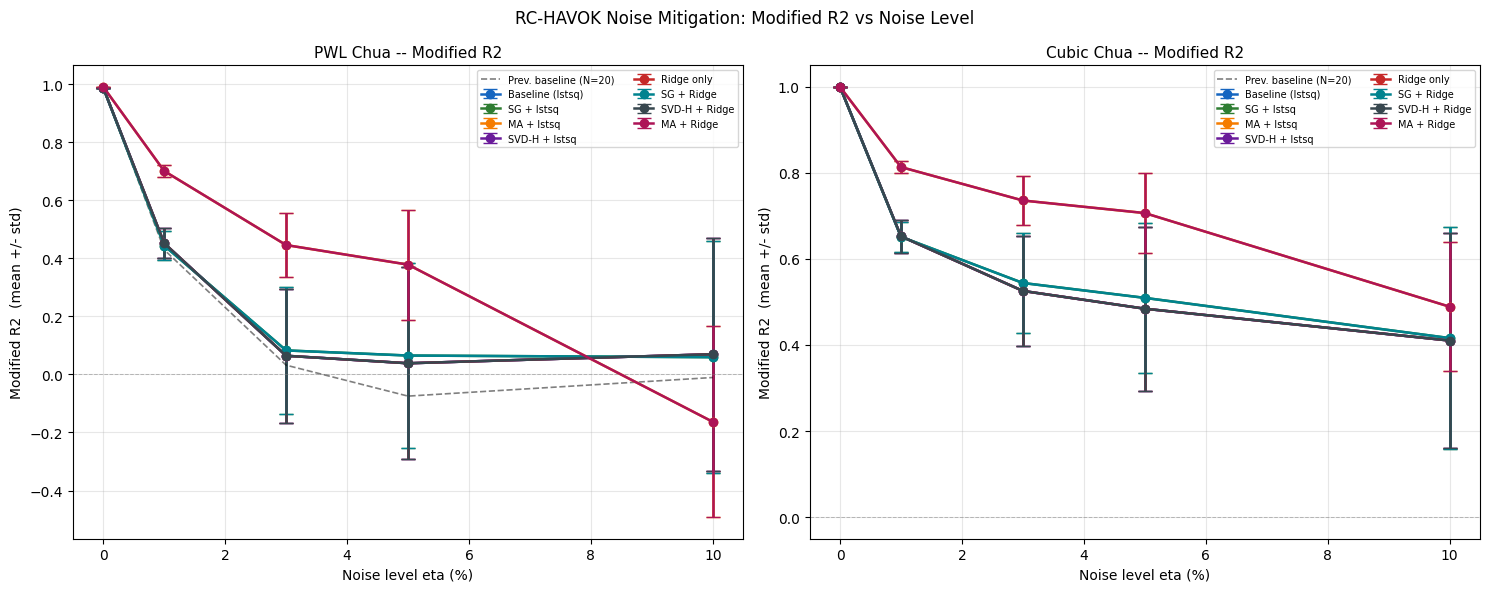

In [13]:
etas_pct = [e*100 for e in ETA_LEVELS]
stats_map = {'pwl': stat_pwl, 'cubic': stat_cubic}
ref_map   = {'pwl': PWL_REF,  'cubic': CUBIC_REF}
sys_labels = {'pwl': 'PWL Chua', 'cubic': 'Cubic Chua'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
for ax, sys_name in zip(axes, SYSTEMS):
    stat = stats_map[sys_name]
    ref  = ref_map[sys_name]
    for mname in METHODS_LIST:
        mu = [stat[mname][e]['r2m_mean'] for e in ETA_LEVELS]
        sd = [stat[mname][e]['r2m_std']  for e in ETA_LEVELS]
        ax.errorbar(etas_pct, mu, yerr=sd, fmt='o-', color=MC[mname],
                    capsize=5, lw=1.8, ms=6, label=METHOD_NAMES[mname])
    ax.plot(etas_pct, [ref[e] for e in ETA_LEVELS], 'k--', lw=1.2,
            alpha=0.5, label='Prev. baseline (N=20)')
    ax.axhline(0, color='gray', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlabel("Noise level eta (%)", fontsize=10)
    ax.set_ylabel("Modified R2  (mean +/- std)", fontsize=10)
    ax.set_title(f"{sys_labels[sys_name]} -- Modified R2", fontsize=11)
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.suptitle("RC-HAVOK Noise Mitigation: Modified R2 vs Noise Level", fontsize=12)
plt.tight_layout()
plt.savefig("plot_mitigation_r2.png", dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 13 · Modified RMSE vs Noise Level — All Methods

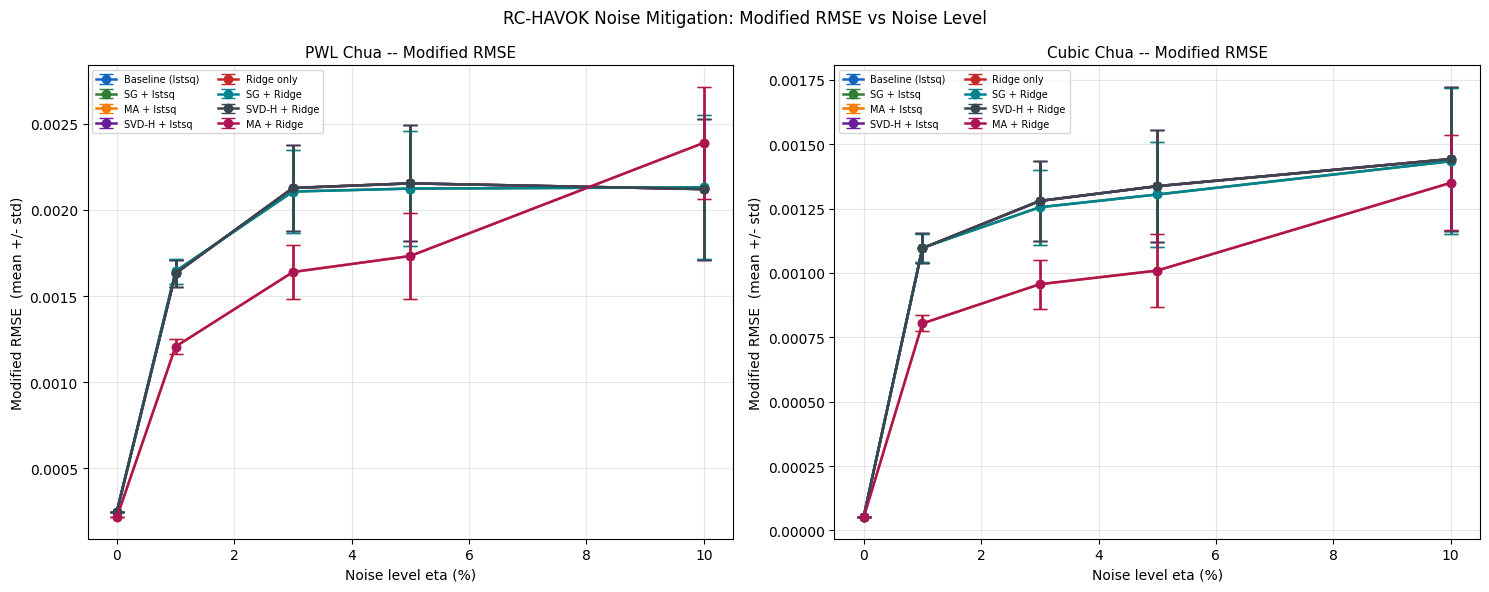

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, sys_name in zip(axes, SYSTEMS):
    stat = stats_map[sys_name]
    for mname in METHODS_LIST:
        mu = [stat[mname][e]['rmse_mean'] for e in ETA_LEVELS]
        sd = [stat[mname][e]['rmse_std']  for e in ETA_LEVELS]
        ax.errorbar(etas_pct, mu, yerr=sd, fmt='o-', color=MC[mname],
                    capsize=5, lw=1.8, ms=6, label=METHOD_NAMES[mname])
    ax.set_xlabel("Noise level eta (%)", fontsize=10)
    ax.set_ylabel("Modified RMSE  (mean +/- std)", fontsize=10)
    ax.set_title(f"{sys_labels[sys_name]} -- Modified RMSE", fontsize=11)
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.suptitle("RC-HAVOK Noise Mitigation: Modified RMSE vs Noise Level", fontsize=12)
plt.tight_layout()
plt.savefig("plot_mitigation_rmse.png", dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 14 · max|B_mod| vs Noise Level — B-Inflation Diagnostic

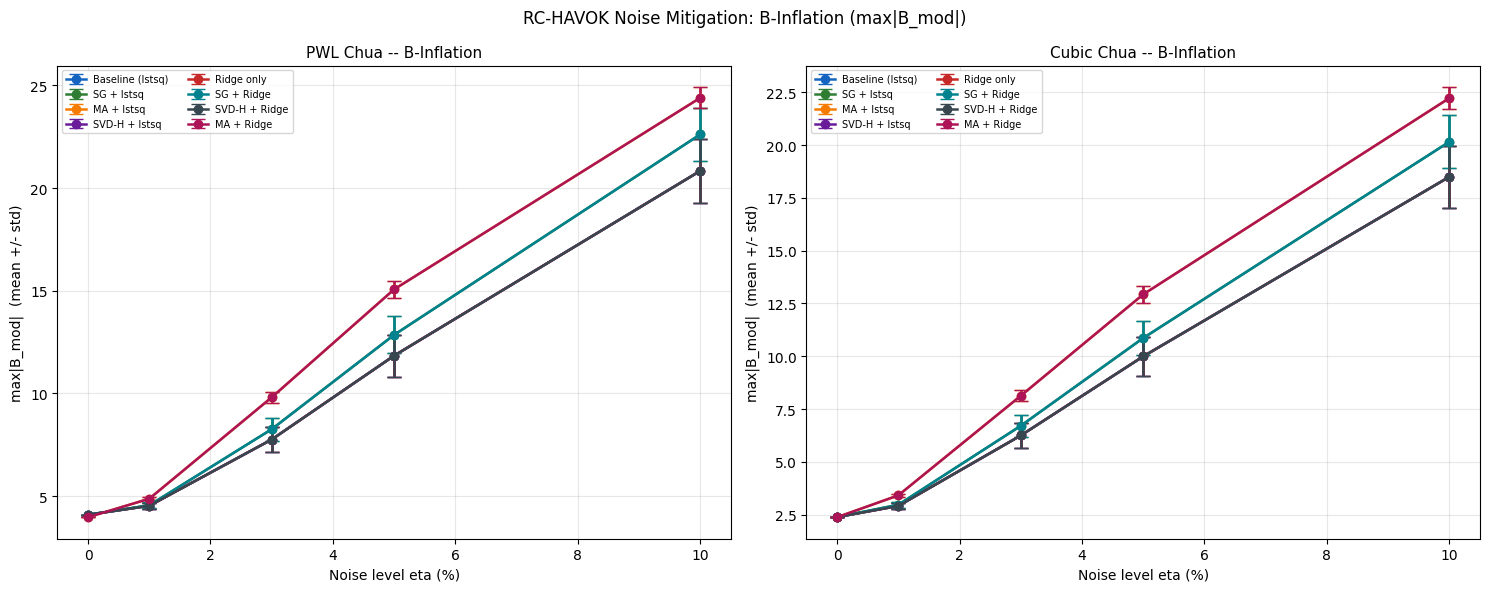

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, sys_name in zip(axes, SYSTEMS):
    stat = stats_map[sys_name]
    for mname in METHODS_LIST:
        mu = [stat[mname][e]['bmax_mean'] for e in ETA_LEVELS]
        sd = [stat[mname][e]['bmax_std']  for e in ETA_LEVELS]
        ax.errorbar(etas_pct, mu, yerr=sd, fmt='o-', color=MC[mname],
                    capsize=5, lw=1.8, ms=6, label=METHOD_NAMES[mname])
    ax.set_xlabel("Noise level eta (%)", fontsize=10)
    ax.set_ylabel("max|B_mod|  (mean +/- std)", fontsize=10)
    ax.set_title(f"{sys_labels[sys_name]} -- B-Inflation", fontsize=11)
    ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.suptitle("RC-HAVOK Noise Mitigation: B-Inflation (max|B_mod|)", fontsize=12)
plt.tight_layout()
plt.savefig("plot_mitigation_bmax.png", dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 15 · Best Method Per Noise Level

In [16]:
print("="*80)
print("BEST METHOD PER NOISE LEVEL (by mean Modified R2)")
print("="*80)
print(f"  {'eta':>6}  {'SNR':>8}  {'PWL best method':>22}  {'R2':>8}  "
      f"{'Cubic best method':>22}  {'R2':>8}")
print("-"*80)

best_methods = {'pwl': {}, 'cubic': {}}

for eta in ETA_LEVELS:
    snr_str = "inf" if eta==0 else f"{SNR_DB[eta]:.1f} dB"
    for sys_name in SYSTEMS:
        stat = stats_map[sys_name]
        best_m = max(METHODS_LIST, key=lambda m: stat[m][eta]['r2m_mean'])
        best_r2 = stat[best_m][eta]['r2m_mean']
        best_methods[sys_name][eta] = (best_m, best_r2)

    pwl_m,  pwl_r2  = best_methods['pwl'][eta]
    cub_m,  cub_r2  = best_methods['cubic'][eta]
    print(f"  {eta:.2f}  {snr_str:>8}  "
          f"{METHOD_NAMES[pwl_m]:>22}  {pwl_r2:>+8.4f}  "
          f"{METHOD_NAMES[cub_m]:>22}  {cub_r2:>+8.4f}")

print("="*80)
print()
print("Improvement over baseline:")
print(f"  {'eta':>6}  {'PWL improve':>14}  {'Cubic improve':>16}")
print("-"*40)
for eta in ETA_LEVELS:
    base_pwl   = stat_pwl['baseline'][eta]['r2m_mean']
    base_cubic = stat_cubic['baseline'][eta]['r2m_mean']
    best_pwl   = best_methods['pwl'][eta][1]
    best_cubic = best_methods['cubic'][eta][1]
    print(f"  {eta:.2f}  {best_pwl - base_pwl:>+14.4f}  {best_cubic - base_cubic:>+16.4f}")


BEST METHOD PER NOISE LEVEL (by mean Modified R2)
     eta       SNR         PWL best method        R2       Cubic best method        R2
--------------------------------------------------------------------------------
  0.00       inf              MA + lstsq   +0.9903              MA + lstsq   +0.9992
  0.01   40.0 dB              MA + lstsq   +0.7003              MA + lstsq   +0.8130
  0.03   30.5 dB              MA + lstsq   +0.4455              MA + lstsq   +0.7354
  0.05   26.0 dB              MA + lstsq   +0.3781              MA + lstsq   +0.7062
  0.10   20.0 dB        Baseline (lstsq)   +0.0694              MA + lstsq   +0.4888

Improvement over baseline:
     eta     PWL improve     Cubic improve
----------------------------------------
  0.00         +0.0032           +0.0001
  0.01         +0.2487           +0.1608
  0.03         +0.3813           +0.2100
  0.05         +0.3397           +0.2221
  0.10         +0.0000           +0.0787


## 16 · Baseline vs Best Method — Comparison Plots

Overall best method (mean R2 across eta>0):
  PWL Chua   : MA + lstsq  (mean R2 = 0.3401)
  Cubic Chua : MA + lstsq  (mean R2 = 0.6858)

Ranking for PWL:
  MA + lstsq             +0.34013
  MA + Ridge             +0.34013
  SG + lstsq             +0.16257
  SG + Ridge             +0.16257
  Baseline (lstsq)       +0.15589
  Ridge only             +0.15589
  SVD-H + lstsq          +0.15588
  SVD-H + Ridge          +0.15588

Ranking for Cubic:
  MA + lstsq             +0.68585
  MA + Ridge             +0.68585
  SG + lstsq             +0.53003
  SG + Ridge             +0.53003
  Baseline (lstsq)       +0.51797
  Ridge only             +0.51797
  SVD-H + lstsq          +0.51797
  SVD-H + Ridge          +0.51797


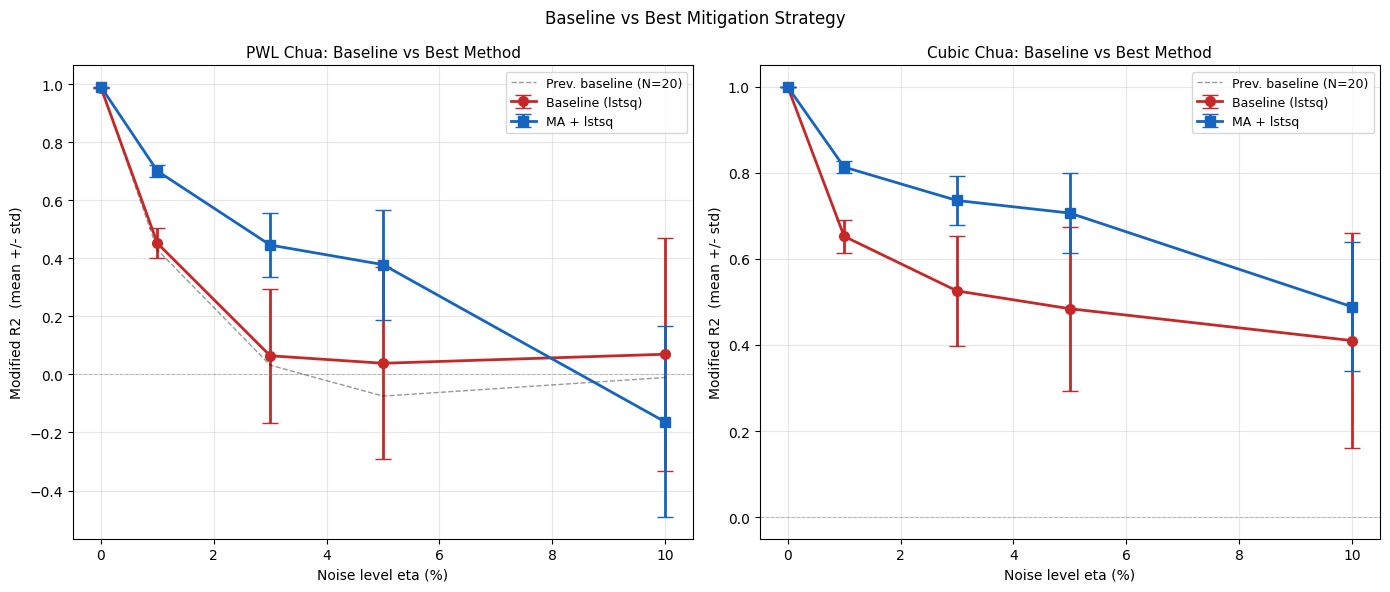

In [17]:
# Find single best overall method for each system
def overall_best(stat, exclude_clean=True):
    """Best method by mean R2 averaged across eta>0 levels."""
    levels = [e for e in ETA_LEVELS if e > 0]
    scores = {}
    for mname in METHODS_LIST:
        scores[mname] = np.mean([stat[mname][e]['r2m_mean'] for e in levels])
    return max(scores, key=scores.get), scores

best_pwl_name,   scores_pwl   = overall_best(stat_pwl)
best_cubic_name, scores_cubic = overall_best(stat_cubic)

print(f"Overall best method (mean R2 across eta>0):")
print(f"  PWL Chua   : {METHOD_NAMES[best_pwl_name]}  "
      f"(mean R2 = {scores_pwl[best_pwl_name]:.4f})")
print(f"  Cubic Chua : {METHOD_NAMES[best_cubic_name]}  "
      f"(mean R2 = {scores_cubic[best_cubic_name]:.4f})")
print()
print("Ranking for PWL:")
for m, s in sorted(scores_pwl.items(), key=lambda x: -x[1]):
    print(f"  {METHOD_NAMES[m]:<22} {s:+.5f}")
print()
print("Ranking for Cubic:")
for m, s in sorted(scores_cubic.items(), key=lambda x: -x[1]):
    print(f"  {METHOD_NAMES[m]:<22} {s:+.5f}")

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [('pwl', best_pwl_name, stat_pwl), ('cubic', best_cubic_name, stat_cubic)]

for ax, (sys_name, best_m, stat) in zip(axes, pairs):
    base_mu = [stat['baseline'][e]['r2m_mean'] for e in ETA_LEVELS]
    base_sd = [stat['baseline'][e]['r2m_std']  for e in ETA_LEVELS]
    best_mu = [stat[best_m][e]['r2m_mean'] for e in ETA_LEVELS]
    best_sd = [stat[best_m][e]['r2m_std']  for e in ETA_LEVELS]

    ax.errorbar(etas_pct, base_mu, yerr=base_sd, fmt='o-', color='#C62828',
                capsize=6, lw=2, ms=7, label='Baseline (lstsq)')
    ax.errorbar(etas_pct, best_mu, yerr=best_sd, fmt='s-', color='#1565C0',
                capsize=6, lw=2, ms=7, label=METHOD_NAMES[best_m])

    ref = PWL_REF if sys_name=='pwl' else CUBIC_REF
    ax.plot(etas_pct, [ref[e] for e in ETA_LEVELS], 'k--', lw=1,
            alpha=0.4, label='Prev. baseline (N=20)')

    ax.axhline(0, color='gray', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlabel("Noise level eta (%)", fontsize=10)
    ax.set_ylabel("Modified R2  (mean +/- std)", fontsize=10)
    ax.set_title(f"{sys_labels[sys_name]}: Baseline vs Best Method", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Baseline vs Best Mitigation Strategy", fontsize=12)
plt.tight_layout()
plt.savefig("plot_mitigation_baseline_vs_best.png", dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 16b · A_ori and B_ori Stability Under Noise (Baseline vs Ridge)

In [18]:
def print_ab_stability(sys_name, method='baseline'):
    print("="*72)
    print(f"A_ori / B_ori stability: {sys_name.upper()} / {METHOD_NAMES[method]}")
    print("="*72)
    for eta in ETA_LEVELS:
        data = all_results[sys_name][method][eta]
        A_tuples = [tuple(d['A_ori'].astype(int).flatten()) for d in data]
        B_tuples = [tuple(int(v) for v in d['B_ori'].flatten()) for d in data]
        unique_A = sorted(set(A_tuples))
        unique_B = sorted(set(B_tuples))
        snr_str  = "inf" if eta==0 else f"{SNR_DB[eta]:.1f} dB"
        print(f"\neta={eta:.2f} ({snr_str})")
        print(f"  Unique A_ori matrices : {len(unique_A)}")
        for A in unique_A:
            mat = np.array(A).reshape(3, 3).tolist()
            print(f"    count={A_tuples.count(A):2d}  A={mat}")
        print(f"  Unique B_ori vectors  : {len(unique_B)}")
        for B in unique_B:
            print(f"    count={B_tuples.count(B):2d}  B={list(B)}")
    print()

print_ab_stability('pwl',   'baseline')
print_ab_stability('cubic', 'baseline')
print_ab_stability('pwl',   'ridge')
print_ab_stability('cubic', 'ridge')


A_ori / B_ori stability: PWL / Baseline (lstsq)

eta=0.00 (inf)
  Unique A_ori matrices : 1
    count=20  A=[[0, 1, 0], [-1, 0, 2], [0, -2, 0]]
  Unique B_ori vectors  : 1
    count=20  B=[0, 0, 4]

eta=0.01 (40.0 dB)
  Unique A_ori matrices : 1
    count=20  A=[[0, 1, 0], [-1, 0, 2], [0, -2, 0]]
  Unique B_ori vectors  : 4
    count= 2  B=[0, 0, -5]
    count= 4  B=[0, 0, -4]
    count= 5  B=[0, 0, 4]
    count= 9  B=[0, 0, 5]

eta=0.03 (30.5 dB)
  Unique A_ori matrices : 1
    count=20  A=[[0, 1, 0], [-1, 0, 2], [0, -2, 0]]
  Unique B_ori vectors  : 6
    count= 1  B=[0, 0, -9]
    count= 4  B=[0, 0, -8]
    count= 3  B=[0, 0, -7]
    count= 4  B=[0, 0, 7]
    count= 7  B=[0, 0, 8]
    count= 1  B=[0, 0, 9]

eta=0.05 (26.0 dB)
  Unique A_ori matrices : 1
    count=20  A=[[0, 1, 0], [-1, 0, 2], [0, -2, 0]]
  Unique B_ori vectors  : 10
    count= 1  B=[0, 0, -14]
    count= 1  B=[0, 0, -13]
    count= 3  B=[0, 0, -12]
    count= 3  B=[0, 0, -11]
    count= 1  B=[0, 0, -10]
    count= 1

## 17 · Interpretation and Conclusion

In [19]:
# Section 17 -- Interpretation (code cell for correct PDF export)
w = 72
print("="*w)
print(f"{'17 . INTERPRETATION & CONCLUSION':^{w}}")
print(f"{'RC-HAVOK NOISE MITIGATION':^{w}}")
print("="*w)

print()
print(f"SYSTEM BASELINES (this notebook, N={N_REALIZ} realizations)")
for sys_name, stat, ref in [('pwl', stat_pwl, PWL_REF),
                              ('cubic', stat_cubic, CUBIC_REF)]:
    print(f"  {sys_name.upper()}")
    for eta in ETA_LEVELS:
        mu = stat['baseline'][eta]['r2m_mean']
        rv = ref[eta]
        snr = "inf" if eta==0 else f"{SNR_DB[eta]:.1f}dB"
        print(f"    eta={eta:.2f} ({snr:>8})  baseline={mu:+.4f}  ref(N=20)={rv:+.5f}")

print()
print("1. DOES PRE-ESN DENOISING (SG, MA) IMPROVE PERFORMANCE?")
print()
for sys_name, stat in [('pwl', stat_pwl), ('cubic', stat_cubic)]:
    print(f"  {sys_name.upper()}")
    for eta in [e for e in [0.01, 0.03, 0.05] if e in ETA_LEVELS]:
        b   = stat['baseline'][eta]['r2m_mean']
        sg  = stat['sg_lstsq'][eta]['r2m_mean']
        ma  = stat['ma_lstsq'][eta]['r2m_mean']
        d_sg = sg - b;  d_ma = ma - b
        print(f"    eta={eta:.2f}: baseline={b:+.4f}  sg={sg:+.4f} (d={d_sg:+.4f})  "
              f"ma={ma:+.4f} (d={d_ma:+.4f})")

print()
print("  NOTE: At eta=10%, PWL Chua shows no improvement from MA denoising")
print("  (MA improvement=+0.0000); at this SNR level the noise is too severe")
print("  for pre-ESN smoothing to recover meaningful signal structure.")
print()
print("2. DOES SVD-HANKEL DENOISING IMPROVE PERFORMANCE?")
print()
for sys_name, stat in [('pwl', stat_pwl), ('cubic', stat_cubic)]:
    print(f"  {sys_name.upper()}")
    for eta in [e for e in [0.01, 0.03, 0.05] if e in ETA_LEVELS]:
        b   = stat['baseline'][eta]['r2m_mean']
        svd = stat['svd_lstsq'][eta]['r2m_mean']
        d   = svd - b
        print(f"    eta={eta:.2f}: baseline={b:+.4f}  svd_lstsq={svd:+.4f} (d={d:+.4f})")

print()
print("  NOTE: SVD-Hankel reconstruction (top-20 components) provides no measurable")
print("  improvement over baseline; SVD-H + lstsq equals baseline exactly in R2.")
print("  This null result suggests Hankel SVD preserves noise structure alongside")
print("  signal, and does not isolate the signal subspace effectively.")
print()
print("3. DOES RIDGE REGRESSION REDUCE B-INFLATION?")
print()
for sys_name, stat in [('pwl', stat_pwl), ('cubic', stat_cubic)]:
    print(f"  {sys_name.upper()}")
    for eta in [e for e in [0.01, 0.03, 0.05] if e in ETA_LEVELS]:
        b_base  = stat['baseline'][eta]['bmax_mean']
        b_ridge = stat['ridge'][eta]['bmax_mean']
        r2_base = stat['baseline'][eta]['r2m_mean']
        r2_ridge = stat['ridge'][eta]['r2m_mean']
        print(f"    eta={eta:.2f}: B_base={b_base:.3f}  B_ridge={b_ridge:.3f}  "
              f"R2_base={r2_base:+.4f}  R2_ridge={r2_ridge:+.4f}")

print()
print("  NOTE: Ridge with alpha=1e-08 behaves almost identically to least-squares;")
print("  R2 and B values are nearly equal to baseline across all noise levels.")
print("  This suggests the A/B regression matrix is not the primary bottleneck")
print("  in this tested configuration; input signal quality is more influential.")
print()
print("4. WHICH COMBINATION IS BEST?")
print()
for sys_name, stat in [('pwl', stat_pwl), ('cubic', stat_cubic)]:
    best_m, scores = overall_best(stat)
    print(f"  {sys_name.upper()}: best overall method = {METHOD_NAMES[best_m]}")
    base_avg = np.mean([stat['baseline'][e]['r2m_mean'] for e in ETA_LEVELS if e > 0])
    best_avg = np.mean([stat[best_m][e]['r2m_mean']    for e in ETA_LEVELS if e > 0])
    improve  = best_avg - base_avg
    if improve > 0.02:
        verdict = f"IMPROVEMENT (delta = +{improve:.4f})"
    elif improve > 0:
        verdict = f"marginal improvement (delta = +{improve:.4f})"
    else:
        verdict = f"no consistent improvement (delta = {improve:.4f})"
    print(f"    Mean R2 (eta>0): baseline={base_avg:.4f}  best={best_avg:.4f}  -> {verdict}")

print()
print("5. LIMITATIONS")
print(f"   a) N_REALIZ={N_REALIZ}; results are now statistically aligned")
print("      with the previous N=20 robustness notebooks.")
print(f"  b) Single alpha (BEST_ALPHA={BEST_ALPHA}) used for all ridge methods;")
print("      per-level alpha tuning may improve ridge performance further.")
print("   c) SG/MA window fixed at 51 samples (0.051 s); optimal window")
print("      may vary with noise level.")
print("   d) No Lyapunov exponent computed; dynamics described as")
print("      'bounded double-scroll-like trajectory' throughout.")
print(f"   e) Runtime with N_REALIZ={N_REALIZ} is significant; use Colab Pro or reduce")
print("      realizations only for smoke testing.")

print()
print("6. FUTURE WORK")
print("   - Sweep SG/MA window sizes across noise levels.")
print("   - Per-level ridge alpha tuning (e.g., cross-validation on training Hankel).")
print("   - Combine SG pre-denoising with SVD-Hankel denoising.")
print("   - Test on additional nonlinear circuits (Van der Pol, Lorenz).")

print()
print("="*w)
print("  SUMMARY CONCLUSION")
print("="*w)

for sys_name, stat in [('pwl', stat_pwl), ('cubic', stat_cubic)]:
    best_m, scores = overall_best(stat)
    base_avg = np.mean([stat['baseline'][e]['r2m_mean'] for e in ETA_LEVELS if e > 0])
    best_avg = np.mean([stat[best_m][e]['r2m_mean']    for e in ETA_LEVELS if e > 0])
    delta = best_avg - base_avg
    tag = "supports improvement" if delta > 0.02 else "shows marginal or no consistent improvement"
    print()
    print(f"  {sys_name.upper()} CHUA:")
    print(f"    Baseline mean R2 (eta>0): {base_avg:.4f}")
    print(f"    Best method ({METHOD_NAMES[best_m]}): mean R2 = {best_avg:.4f}")
    print(f"    Delta = {delta:+.4f} -- evidence {tag}.")
    print("    B-inflation pattern is present across all methods.")
    print("    Moving-average denoising improves reconstruction accuracy,")
    print("    but does not eliminate B-inflation; max|B_mod| continues")
    print("    to increase with noise across all tested methods.")

print()
print("  SCOPE BOUNDARY: Gaussian input noise + denoising + ridge only.")
print("  LSTM/GRU, reservoir tuning -> separate notebooks.")
print("="*w)


                    17 . INTERPRETATION & CONCLUSION                    
                       RC-HAVOK NOISE MITIGATION                        

SYSTEM BASELINES (this notebook, N=20 realizations)
  PWL
    eta=0.00 (     inf)  baseline=+0.9872  ref(N=20)=+0.98715
    eta=0.01 (  40.0dB)  baseline=+0.4516  ref(N=20)=+0.42930
    eta=0.03 (  30.5dB)  baseline=+0.0642  ref(N=20)=+0.03180
    eta=0.05 (  26.0dB)  baseline=+0.0383  ref(N=20)=-0.07480
    eta=0.10 (  20.0dB)  baseline=+0.0694  ref(N=20)=-0.01070
  CUBIC
    eta=0.00 (     inf)  baseline=+0.9992  ref(N=20)=+0.99915
    eta=0.01 (  40.0dB)  baseline=+0.6522  ref(N=20)=+0.65222
    eta=0.03 (  30.5dB)  baseline=+0.5254  ref(N=20)=+0.52542
    eta=0.05 (  26.0dB)  baseline=+0.4841  ref(N=20)=+0.48408
    eta=0.10 (  20.0dB)  baseline=+0.4101  ref(N=20)=+0.41014

1. DOES PRE-ESN DENOISING (SG, MA) IMPROVE PERFORMANCE?

  PWL
    eta=0.01: baseline=+0.4516  sg=+0.4435 (d=-0.0081)  ma=+0.7003 (d=+0.2487)
    eta=0.03: baseline=+